In [1]:
from dataclasses import dataclass
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from typing import List
import random
import time, random
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

In [2]:
@dataclass
class SolomonData:
    coords:   np.ndarray   # (n+1, 2)
    demand:   np.ndarray   # (n+1,)
    ready:    np.ndarray   # (n+1,)
    due:      np.ndarray   # (n+1,)
    service:  np.ndarray   # (n+1,)
    capacity: int          # Q
    k_max:    int          # число машин
    dist:     np.ndarray   # (n+1, n+1)


def _first_ints(tokens: List[str]) -> List[int]:
    """Повертає всі цілі числа з переліку токенів."""
    return [int(t) for t in tokens if t.lstrip("+-").isdigit()]


def parse_solomon(path: str | Path) -> SolomonData:
    """
    Читає будь-який Solomon-файл (.txt) і повертає структуру SolomonData.
    Коректно обробляє формат ‘VEHICLE … CAPACITY’, навіть якщо між числами багато пробілів.
    """
    lines = Path(path).read_text().splitlines()

    # ---------- 1. секція VEHICLE ------------------------------------------------
    veh_idx = lines.index('VEHICLE')
    # рядок 'NUMBER CAPACITY' — ще один рядок
    capacity_line = lines[veh_idx + 2]                # «  25         200»
    veh_num, capacity = _first_ints(capacity_line.split())

    # ---------- 2. секція CUSTOMER -----------------------------------------------
    cust_start = lines.index('CUSTOMER') + 2          # пропускаємо заголовок + порожній
    raw_tokens = [l.split() for l in lines[cust_start:] if l.strip()]
    # фільтруємо дані (у деяких файлах унизу може бути “EOF” тощо)
    raw_tokens = [t for t in raw_tokens if t[0].lstrip("+-").isdigit()]

    arr = np.array(raw_tokens, dtype=float)
    # гарантуємо 0,1,2… по першій колонці (порядок у деяких файлах не гарантовано)
    arr = arr[np.argsort(arr[:, 0])]

    coords   = arr[:, 1:3]
    demand   = arr[:, 3].astype(int)
    ready    = arr[:, 4]
    due      = arr[:, 5]
    service  = arr[:, 6]

    # ---------- 3. попередньо рахуємо матрицю відстаней --------------------------
    dx = coords[:, 0][:, None] - coords[:, 0][None, :]
    dy = coords[:, 1][:, None] - coords[:, 1][None, :]
    dist = np.hypot(dx, dy)

    return SolomonData(coords, demand, ready, due, service,
                       capacity=capacity, k_max=veh_num, dist=dist)

In [3]:
data = parse_solomon("data/c101.txt")

## Функція вартості

In [3]:
def evaluate_solution(tour: list[int],
                      data: SolomonData,
                      lambda_over: int   = 1000,
                      lambda_late: int   = 1000,
                      lambda_depot: int  = 1000,
                      lambda_veh: int    = 10000) -> float:
    """
    ▸ tour  – перестановка клієнтів 1..n (депо 0 не присутній)
    ▸ data  – об’єкт SolomonData
    Повертає: total_cost  – значення цільової функції
    """
    Q, k_max = data.capacity, data.k_max
    ready, due, service, demand = data.ready, data.due, data.service, data.demand
    dist = data.dist

    total_dist   = 0.0
    overload_pen = 0.0
    late_pen     = 0.0
    depot_pen    = 0.0
    routes_used  = 1

    load  = 0
    time  = ready[0]          
    cur   = 0                 
    for cust in tour:
        # Час до клієнта
        travel = dist[cur, cust]
        arrive = time + travel
        start  = max(arrive, ready[cust])
        finish = start + service[cust]

        # Чи поміщається клієнт у поточний маршрут?
        will_overload = load + demand[cust] > Q
        will_be_late  = finish + dist[cust, 0] > due[0]   # повернення у депо

        if will_overload or will_be_late:
            # Закриваємо маршрут і повертаємось у депо
            total_dist += dist[cur, 0]
            depot_pen  += max(0, time + dist[cur, 0] - due[0])

            # Новий маршрут
            routes_used += 1
            load, time, cur = 0, ready[0], 0

            # Обчислюємо значення для того ж клієнта повторно
            travel = dist[cur, cust]
            arrive = time + travel
            start  = max(arrive, ready[cust])
            finish = start + service[cust]

        # Додаємо клієнта у маршрут
        load        += demand[cust]
        overload_pen += max(0, load - Q)         
        late_pen     += max(0, start - due[cust])
        total_dist   += travel
        time, cur    = finish, cust

    # Повернення з останнього маршруту
    total_dist += dist[cur, 0]
    depot_pen  += max(0, time + dist[cur, 0] - due[0])

    extra_veh = max(0, routes_used - k_max)

    return (total_dist
            + lambda_over * overload_pen
            + lambda_late * late_pen
            + lambda_depot * depot_pen
            + lambda_veh * extra_veh), total_dist 


## ACO

In [4]:
import time, random, numpy as np
from dataclasses import dataclass
from typing import List

# ────────────────── параметри ──────────────────
@dataclass
class ACOParams:
    n_ants:   int   = 50
    alpha:    float = 1.0
    beta:     float = 3.0
    rho:      float = 0.1
    q0:       float = 0.6
    tau0:     float = 1e-3
    elitist:  bool  = True

class AntColony:
    def __init__(self, data, params: ACOParams, eval_fn):
        self.data, self.p, self.eval_fn = data, params, eval_fn
        n = len(data.coords)
        self.tau = np.full((n, n), self.p.tau0, dtype=float)
        self.eta = 1.0 / (data.dist + 1e-6)
        self.best_tour: List[int] | None = None
        self.best_cost: float = np.inf
        self.history: list[tuple[int,float,float,float]] = []  

    def _construct_tour(self, rng) -> list[int]:
        n_clients, unvis = len(self.data.coords) - 1, list(range(1, len(self.data.coords)))
        tour, cur = [], 0
        while unvis:
            desir = (self.tau[cur, unvis] ** self.p.alpha) * (self.eta[cur, unvis] ** self.p.beta)
            if rng.random() < self.p.q0:
                nxt = unvis[int(np.argmax(desir))]
            else:
                nxt = rng.choices(unvis, weights=desir/desir.sum(), k=1)[0]
            tour.append(nxt)
            self._local_pheromone_update(cur, nxt)
            unvis.remove(nxt)
            cur = nxt
        self._local_pheromone_update(cur, 0)
        return tour

    def _local_pheromone_update(self, i, j):
        self.tau[i, j] = (1 - self.p.rho) * self.tau[i, j] + self.p.rho * self.p.tau0
        self.tau[j, i] = self.tau[i, j]


    def run(self, *,
        time_limit: float | None = 30.0,
        max_iter:  int   | None = None,
        seed: int | None = None):         

        rng  = random.Random(seed) if seed is not None else random.Random()
        t0   = time.perf_counter()
        it   = 0
        cond = lambda: ((time_limit is None or time.perf_counter() - t0 < time_limit) and
                        (max_iter   is None or it < max_iter))

        while cond():
            ant_tours, ant_costs = [], []
            for _ in range(self.p.n_ants):
                tour   = self._construct_tour(rng)
                cost,_ = self.eval_fn(tour, self.data)
                ant_tours.append(tour); ant_costs.append(cost)
                if cost < self.best_cost:
                    self.best_cost, self.best_tour = cost, tour.copy()
            # запис у історію
            dist = evaluate_solution(self.best_tour, self.data)[1]
            self.history.append((it, time.perf_counter() - t0, self.best_cost, dist))

            # глобальний апдейт
            self.tau *= (1 - self.p.rho)
            deposits = [(self.best_tour, self.best_cost)] if self.p.elitist else zip(ant_tours, ant_costs)
            for tour, cost in deposits:
                delta, cur = 1.0 / cost, 0
                for nxt in tour:
                    self.tau[cur, nxt] += delta; self.tau[nxt, cur] += delta
                    cur = nxt
                self.tau[cur, 0] += delta; self.tau[0, cur] += delta
            it += 1

        return self.best_cost, self.best_tour


In [5]:

params = ACOParams(
    n_ants  = 50,
    alpha   = 1.0,
    beta    = 3.0,
    rho     = 0.3,
    q0      = 0.4,
    tau0    = 1e-3,
    elitist = False,
)


aco = AntColony(data, params, evaluate_solution)
best_cost_ant, best_tour_ant = aco.run(time_limit=30.0)      

print(f"ACO best cost = {best_cost_ant:.2f}")

NameError: name 'data' is not defined

In [15]:
evaluate_solution(best_tour_ant, data)

(np.float64(15045485.10346913), np.float64(1256.5589947459423))

In [16]:
aco.history

[(0,
  0.23111269999935757,
  np.float64(19737192.660103668),
  np.float64(1583.066682642633)),
 (1,
  0.3590184000058798,
  np.float64(19737192.660103668),
  np.float64(1583.066682642633)),
 (2,
  0.4789965000018128,
  np.float64(19737192.660103668),
  np.float64(1583.066682642633)),
 (3,
  0.6003435000020545,
  np.float64(19684568.2357825),
  np.float64(1451.3987531947546)),
 (4,
  0.7235077000004821,
  np.float64(19684568.2357825),
  np.float64(1451.3987531947546)),
 (5,
  0.8465895000044839,
  np.float64(19684568.2357825),
  np.float64(1451.3987531947546)),
 (6,
  0.9669251000013901,
  np.float64(19684568.2357825),
  np.float64(1451.3987531947546)),
 (7,
  1.0904758000033326,
  np.float64(19684568.2357825),
  np.float64(1451.3987531947546)),
 (8,
  1.2198516999997082,
  np.float64(19684568.2357825),
  np.float64(1451.3987531947546)),
 (9,
  1.35275140000158,
  np.float64(19684568.2357825),
  np.float64(1451.3987531947546)),
 (10,
  1.4745728000052623,
  np.float64(19684568.2357825)

## Genetic

In [ ]:
@dataclass
class Individual:
    tour: List[int]
    cost: float

class GeneticVRPTW:
    """ GA для giant-tour VRPTW з тайм-лімітом та історією."""
    def __init__(self, data, eval_fn,
                 pop_size=300,
                 crossover_rate=0.9, mutation_rate=0.2,
                 tournament_k=3, rng_seed: int | None = None):

        self.data, self.eval = data, eval_fn
        self.N               = len(data.coords) - 1
        self.pop_size        = pop_size
        self.cx_rate, self.mut_rate = crossover_rate, mutation_rate
        self.k               = tournament_k
        self.rng             = random.Random(rng_seed) if rng_seed is not None else random.Random()


        # ---------- випадкова початкова популяція --------------------
        base = list(range(1, self.N + 1))
        self.pop: List[Individual] = []
        for _ in range(pop_size):
            self.rng.shuffle(base)
            cost, _ = self.eval(base, data)
            self.pop.append(Individual(base[:], cost))
        self.best    = min(self.pop, key=lambda ind: ind.cost)
        self.history: list[tuple[int,float,float,float]] = []  

    # ---------- оператори -------------------------------------------
    def _order_crossover(self, p1, p2):
        n = len(p1)
        a, b = sorted(self.rng.sample(range(n), 2))
        child = [None]*n
        child[a:b] = p1[a:b]
        pos = b
        for g in p2:
            if g not in child:
                if pos == n: pos = 0
                child[pos] = g; pos += 1
        return child

    def _swap_mutation(self, tour):
        i, j = self.rng.sample(range(len(tour)), 2)
        tour[i], tour[j] = tour[j], tour[i]

    def _tournament(self):
        return min(self.rng.sample(self.pop, self.k), key=lambda ind: ind.cost)

    
    def run(self, *, time_limit: float | None = 30.0,
                  max_gen:   int   | None = None):

        t0  = time.perf_counter()
        gen = 0
        cond = lambda: ((time_limit is None or time.perf_counter() - t0 < time_limit) and
                        (max_gen   is None or gen < max_gen))

        while cond():
            
            new_pop = [Individual(self.best.tour[:], self.best.cost)]

            while len(new_pop) < self.pop_size:
                
                while True:
                    p1, p2 = self._tournament(), self._tournament()
                    if p1 is not p2: break

                # кросовер 
                child_tour = (self._order_crossover(p1.tour, p2.tour)
                              if self.rng.random() < self.cx_rate
                              else p1.tour[:])

                # мутація
                if self.rng.random() < self.mut_rate:
                    self._swap_mutation(child_tour)

                # оцінка
                child_cost, _ = self.eval(child_tour, self.data)
                new_pop.append(Individual(child_tour, child_cost))

            self.pop = new_pop
            cand = min(self.pop, key=lambda ind: ind.cost)
            if cand.cost < self.best.cost:
                self.best = cand

            dist = evaluate_solution(self.best.tour, self.data)[1]
            self.history.append((gen, time.perf_counter() - t0, self.best.cost, dist))
            gen += 1

        return self.best.cost, self.best.tour

In [ ]:

ga = GeneticVRPTW(
    data,
    eval_fn = evaluate_solution, 
    pop_size = 200,
    crossover_rate = 0.9,
    mutation_rate = 0.8,
    tournament_k = 5,
    rng_seed = 123,
)


best_cost_ga, best_tour_ga = ga.run(time_limit=30.0)
print(f"GA best cost = {best_cost_ga:.2f}")

GA best cost = 8941006.67


In [19]:
evaluate_solution(best_tour_ga, data)

(np.float64(8941006.670646138), np.float64(4097.628691229054))

In [20]:
ga.history

[(0,
  0.056590100000903476,
  np.float64(19489628.56987898),
  np.float64(4213.694942287668)),
 (1,
  0.11058350000530481,
  np.float64(19405593.37398598),
  np.float64(4199.820921185423)),
 (2,
  0.1660900999995647,
  np.float64(19270430.78254221),
  np.float64(4204.800976764872)),
 (3,
  0.22194790000503417,
  np.float64(19170792.793405738),
  np.float64(4253.995647823415)),
 (4,
  0.2755719999986468,
  np.float64(18728715.353082776),
  np.float64(4330.583419593893)),
 (5,
  0.3303468000012799,
  np.float64(17899124.02163592),
  np.float64(4263.320059434985)),
 (6,
  0.3850758000044152,
  np.float64(17899124.02163592),
  np.float64(4263.320059434985)),
 (7,
  0.4401724999988801,
  np.float64(17750134.004261244),
  np.float64(4313.518351198031)),
 (8,
  0.4976574000029359,
  np.float64(17646491.752735425),
  np.float64(4152.0428105863975)),
 (9,
  0.551878600002965,
  np.float64(17182755.640958294),
  np.float64(4377.435539106893)),
 (10,
  0.6070251999990433,
  np.float64(17022370.8

## TabuSearch

In [ ]:
Move = Tuple[int, int, str]     

@dataclass
class TabuParams:
    tenure:     int   = 20
    neigh_size: int   = 200
    swap_rate:  float = 0.5
    rng_seed:   int | None = None   

class TabuSearchVRPTW:
    def __init__(self, data, eval_fn, params: TabuParams = TabuParams()):
        self.data, self.eval, self.p = data, eval_fn, params
        self.rng = random.Random(self.p.rng_seed) if self.p.rng_seed is not None else random.Random()

        self.tour = list(range(1, len(data.coords)))
        self.rng.shuffle(self.tour)
        self.cost = self.eval(self.tour, self.data)[0]

        self.best_tour, self.best_cost = self.tour[:], self.cost
        self.tabu: deque[Tuple[Move, int]] = deque()
        self.history: list[tuple[int, float, float,float]] = []  

    
    def _apply_move(self, tour: List[int], move: Move) -> None:
        i, j, mtype = move
        if mtype == "swap":
            tour[i], tour[j] = tour[j], tour[i]
        else:                       # relocate
            city = tour.pop(i)
            tour.insert(j if j < i else j - 1, city)

    def _random_move(self, n: int) -> Move:
        i, j = self.rng.sample(range(n), 2)
        return (min(i, j), max(i, j), "swap") if self.rng.random() < self.p.swap_rate else (i, j, "reloc")

    # -------- основний цикл ----------------
    def run(self, *, time_limit: float | None = 30.0,
                   max_iter:  int   | None = None):

        n, it = len(self.tour), 0
        t0 = time.perf_counter()
        cond = lambda: ((time_limit is None or time.perf_counter() - t0 < time_limit) and
                        (max_iter   is None or it < max_iter))

        while cond():
            best_cand, best_move = None, None
            best_cand_cost = float("inf")

            for _ in range(self.p.neigh_size):
                move = self._random_move(n)
                cand = self.tour[:]
                self._apply_move(cand, move)
                c_cost = self.eval(cand, self.data)[0]

                tabu_now = any(mv == move for mv, exp in self.tabu if exp >= it)
                if not tabu_now or c_cost < self.best_cost:
                    if c_cost < best_cand_cost:
                        best_cand, best_cand_cost, best_move = cand, c_cost, move

            self.tour, self.cost = best_cand, best_cand_cost
            if self.cost < self.best_cost:
                self.best_cost, self.best_tour = self.cost, self.tour[:]

            self.tabu.append((best_move, it + self.p.tenure))
            while self.tabu and self.tabu[0][1] <= it:
                self.tabu.popleft()
            dist = evaluate_solution(self.best_tour, self.data)[1]
            self.history.append((it, time.perf_counter() - t0, self.best_cost, dist))
            it += 1

        return self.best_cost, self.best_tour

In [22]:
ts = TabuSearchVRPTW(data, evaluate_solution,
                     TabuParams(tenure=15,
                                neigh_size=250))

best_cost_tabu, best_tour_tabu = ts.run(time_limit=30.0)
print(f"Tabu Search best cost = {best_cost_tabu:.2f}")

Tabu Search best cost = 1330118.87


In [23]:
evaluate_solution(best_tour_tabu, data)

(np.float64(1330118.8652347361), np.float64(3074.030479029212))

In [24]:
ts.history

[(0,
  0.08205680000537541,
  np.float64(22466913.170036867),
  np.float64(4089.4495332282727)),
 (1,
  0.1342067000005045,
  np.float64(20876144.053295806),
  np.float64(4218.24706064016)),
 (2,
  0.1774208000060753,
  np.float64(19264790.955779646),
  np.float64(4198.931890603564)),
 (3,
  0.2211042000053567,
  np.float64(17869490.429452028),
  np.float64(4213.544037502043)),
 (4,
  0.26498790000187,
  np.float64(17001303.316891238),
  np.float64(4293.524323784119)),
 (5,
  0.30842180000036024,
  np.float64(16442034.958284076),
  np.float64(4315.418035512285)),
 (6,
  0.3582044000067981,
  np.float64(15544077.631497385),
  np.float64(4320.225617237331)),
 (7,
  0.40234870000131195,
  np.float64(14964672.487154024),
  np.float64(4384.511508729202)),
 (8,
  0.4458283000058145,
  np.float64(14396270.603163168),
  np.float64(4375.6128006267)),
 (9,
  0.4894690000000992,
  np.float64(13895333.581510229),
  np.float64(4364.3119571686975)),
 (10,
  0.5327431000041543,
  np.float64(13543448.

## Графіки маршрутів

In [6]:
def split_routes(tour: list[int], data):
    """
    Розбиває giant-tour на послідовність маршрутів, використовуючи
    ті самі перевірки вантажу та часових вікон, що й evaluate_solution().

    Параметри
    ---------
    tour : List[int]
        Перестановка клієнтів 1..n (депо 0 не присутній)
    data : SolomonData
        Об’єкт із parse_solomon()  – містить capacity, ready, due, service, demand, dist

    Повертає
    --------
    List[List[int]]
        Список маршрутів; кожен – список клієнтів без 0 на краях
    """
    Q, ready, due, service, demand, dist = (
        data.capacity, data.ready, data.due, data.service, data.demand, data.dist
    )

    routes   = []
    route    = []
    load     = 0
    time_cur = ready[0]       
    cur      = 0              

    for cust in tour:
        travel = dist[cur, cust]
        arrive = time_cur + travel
        start  = max(arrive, ready[cust])
        finish = start + service[cust]

        overload   = load + demand[cust] > Q
        late_depot = finish + dist[cust, 0] > due[0]      # не встигне повернутися

        # якщо перевантаження або не встигаємо до депо → закриваємо маршрут
        if overload or late_depot:
            routes.append(route)
            route    = []
            load     = 0
            time_cur = ready[0]
            cur      = 0
            # переоцінюємо того ж клієнта для нового маршруту
            travel  = dist[cur, cust]
            arrive  = time_cur + travel
            start   = max(arrive, ready[cust])
            finish  = start + service[cust]

        # додаємо клієнта у поточний маршрут
        route.append(cust)
        load     += demand[cust]
        time_cur  = finish
        cur       = cust

    # останній маршрут
    routes.append(route)
    return routes

# ------------ plotting helper ---------------------------------------
def plot_solution(tour, data, label):
    routes = split_routes(tour, data)
    coords = data.coords
    for r in routes:
        pts = [0] + r + [0]                 # depot -> ... -> depot
        xs, ys = coords[pts, 0], coords[pts, 1]
        plt.plot(xs, ys, marker='o', linewidth=1, label=f'{label} route' if r==routes[0] else None)

    plt.scatter(coords[0,0], coords[0,1], marker='s', s=100, label='Depot')



In [7]:
def plot_solution_subplots(tour, data, label="Solution"):
    routes = split_routes(tour, data)
    coords = data.coords
    n = len(routes)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)
    fig.suptitle(f"{label}: {n} routes", fontsize=14)

    for idx, (ax, route) in enumerate(zip(axes.flat, routes)):
        pts = [0] + route + [0]
        xs, ys = coords[pts, 0], coords[pts, 1]
        ax.plot(xs, ys, marker='o')
        ax.scatter(coords[0,0], coords[0,1], marker='s', s=60, color='red', label='Depot')
        ax.set_title(f"Route {idx+1} ({len(route)} cust)")
        ax.set_aspect('equal')
        ax.axis('off')

    # hide any unused subplots
    for ax in axes.flat[len(routes):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Benchmark алгоритмів

In [8]:
def benchmark_algorithm(make_algo, n_runs=5, run_kwargs=None, algo_name: str = ""):
    """
    make_algo() → новий об’єкт із .run(**run_kwargs) та
    .history = [(iter, t, best_cost, best_dist), …].
    Малює:
        •   n кривих best-cost   + усереднену,
        •   n кривих distance    + усереднену.
    Повертає (results_cost, results_dist), histories
    """
    title_prefix = f"{algo_name}: " if algo_name else ""
    run_kwargs = run_kwargs or {}
    results_cost, results_dist, histories = [], [], []
    best_overall_cost = float("inf")
    best_overall_tour = None
    # ---------- запуски ---------------------------------
    for _ in range(n_runs):
        algo = make_algo()
        best_cost, _ = algo.run(**run_kwargs)
        if hasattr(algo, "best_tour"):        # ACO, Tabu Search
            tour = algo.best_tour
        else:                                 # GA: має best (Individual)
            tour = algo.best.tour
        best_dist = evaluate_solution(tour, algo.data)[1]
        
        # зберігаємо top-1 тур
        if best_cost < best_overall_cost:
            best_overall_cost = best_cost
            best_overall_tour = tour.copy()
        
        results_cost.append(best_cost)
        results_dist.append(best_dist)
        histories.append(algo.history)



    # ---------- підготовка усереднених кривих -----------
    max_len = max(len(h) for h in histories)
    mean_cost = np.zeros(max_len)
    mean_dist = np.zeros(max_len)

    plt.figure(figsize=(7, 6))

    # --- Subplot 1: cost --------------------------------
    ax1 = plt.subplot(2, 1, 1)
    for idx, hist in enumerate(histories):
        it   = [h[0] for h in hist]
        cost = [h[2] for h in hist]
        ax1.plot(it, cost, alpha=0.6, linewidth=1)
        mean_cost += np.pad(cost, (0, max_len-len(cost)), constant_values=cost[-1])
    mean_cost /= n_runs
    ax1.plot(range(max_len), mean_cost, color='black', linewidth=1.5, label='mean')
    ax1.set_ylabel("best cost")
    ax1.set_title(f"{title_prefix}{n_runs} runs – cost")
    ax1.legend()

    # --- Subplot 2: distance ----------------------------
    ax2 = plt.subplot(2, 1, 2)
    for idx, hist in enumerate(histories):
        it   = [h[0] for h in hist]
        dist = [h[3] for h in hist]
        ax2.plot(it, dist, alpha=0.6, linewidth=0.8)
        mean_dist += np.pad(dist, (0, max_len-len(dist)), constant_values=dist[-1])
    mean_dist /= n_runs
    ax2.plot(range(max_len), mean_dist, color='black', linewidth=2, label='mean')
    ax2.set_xlabel("iteration")
    ax2.set_ylabel("best distance")
    ax2.set_title(f"{title_prefix}distance")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f" COST  – min {min(results_cost):.2f} | "
          f"avg {np.mean(results_cost):.2f} | max {max(results_cost):.2f}")
    print(f" DIST  – min {min(results_dist):.2f} | "
          f"avg {np.mean(results_dist):.2f} | max {max(results_dist):.2f}")

    return (results_cost, results_dist), histories, best_overall_tour


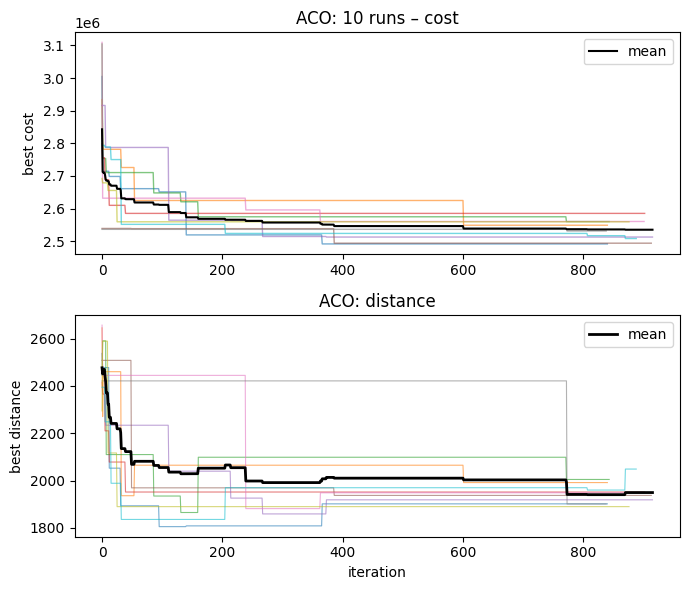

 COST  – min 2491404.42 | avg 2534961.06 | max 2584992.51
 DIST  – min 1889.96 | avg 1949.43 | max 2048.73


In [113]:
params = ACOParams(
    n_ants  = 25,
    alpha   = 1.0,
    beta    = 1.5,
    rho     = 0.2,
    q0      = 0.3,
    tau0    = 1e-3,
    elitist = False,
)
make_aco = lambda: AntColony(data, params, evaluate_solution)
results_aco, histories_aco, best_tour_aco = benchmark_algorithm(make_aco,
                                         n_runs=10,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="ACO")

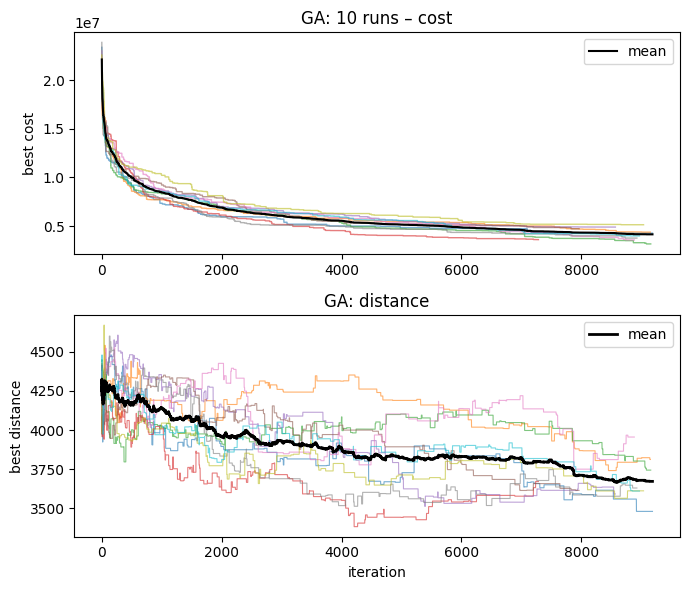

 COST  – min 3171845.28 | avg 4155713.68 | max 5140755.60
 DIST  – min 3480.26 | avg 3672.15 | max 3955.61


In [62]:
make_ga = lambda: GeneticVRPTW(data, evaluate_solution, pop_size=25, tournament_k=5, mutation_rate=0.8, crossover_rate=0.9)
results_ga, histories_ga, best_tour_ga = benchmark_algorithm(make_ga,
                                         n_runs=10,
                                         run_kwargs={"time_limit": 60.0}, 
                                         algo_name="GA")

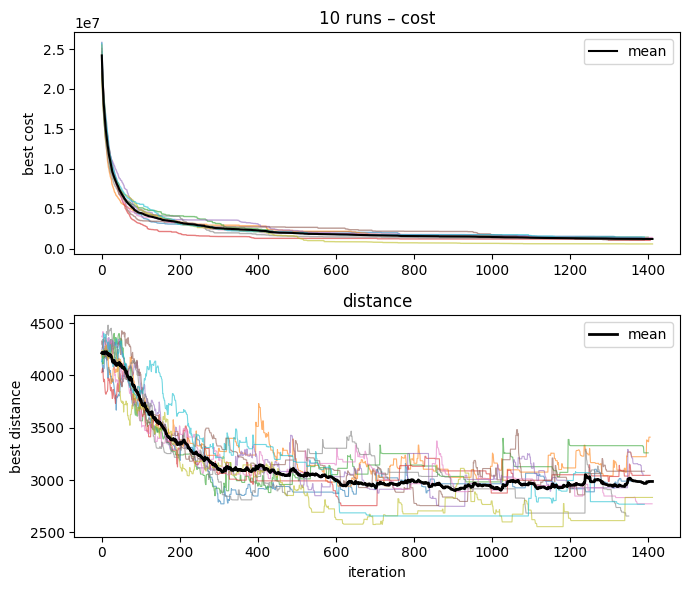

 COST  – min 586228.99 | avg 1208464.63 | max 1435677.21
 DIST  – min 2655.69 | avg 2986.31 | max 3410.03


In [63]:
tabu_params = TabuParams(tenure=15, neigh_size=250)
make_tabu = lambda: TabuSearchVRPTW(data, evaluate_solution, tabu_params)
results_tabu, histories_tabu, best_tour_tabu = benchmark_algorithm(make_tabu,
                                         n_runs=10,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="Tabu")

In [73]:
data2 = parse_solomon("data/r101.txt")


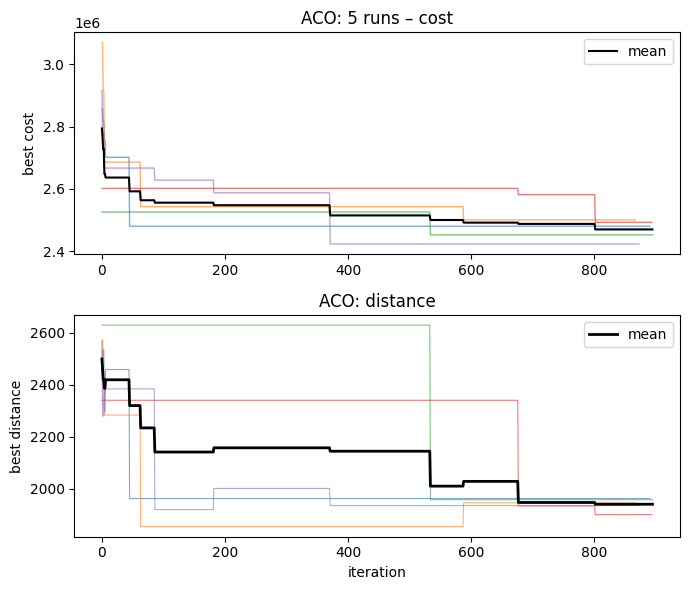

 COST  – min 2423103.44 | avg 2469665.94 | max 2500398.61
 DIST  – min 1901.07 | avg 1941.11 | max 1963.06


In [114]:
make_aco2 = lambda: AntColony(data2, params, evaluate_solution)
results_aco2, histories_aco2, best_tour_aco2 = benchmark_algorithm(make_aco2,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="ACO")


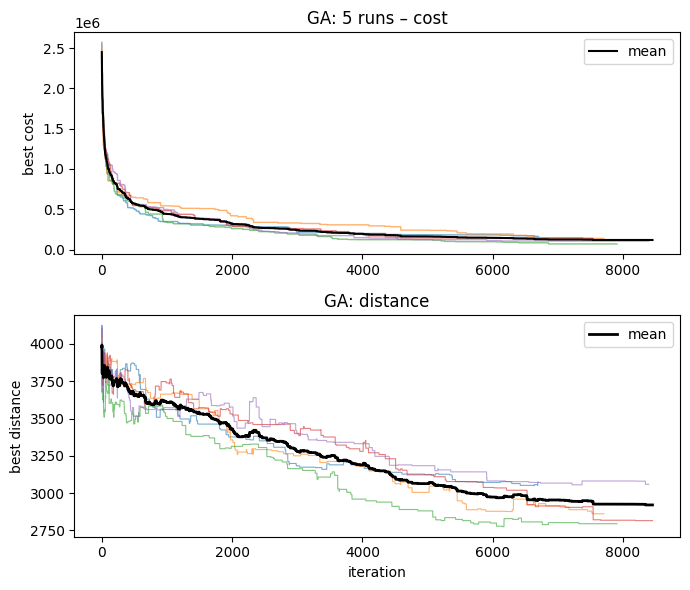

 COST  – min 69401.78 | avg 118311.21 | max 161616.55
 DIST  – min 2795.04 | avg 2920.85 | max 3073.03


In [83]:
make_ga2 = lambda: GeneticVRPTW(data2, evaluate_solution, pop_size=25, tournament_k=5, mutation_rate=0.8, crossover_rate=0.9)
results_ga2, histories_ga2, best_tour_ga2 = benchmark_algorithm(make_ga2,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0}, 
                                         algo_name="GA")


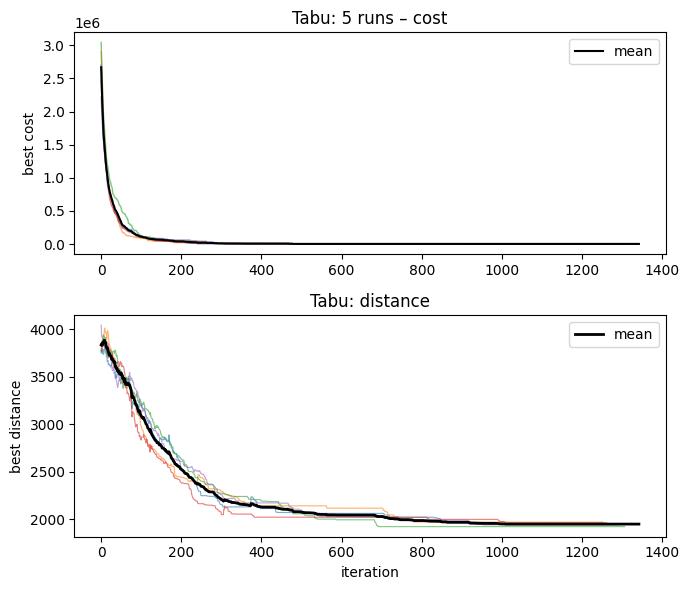

 COST  – min 1919.95 | avg 1946.90 | max 1967.86
 DIST  – min 1919.95 | avg 1946.90 | max 1967.86


In [84]:
make_tabu2 = lambda: TabuSearchVRPTW(data2, evaluate_solution, tabu_params)
results_tabu2, histories_tabu2, best_tour_tabu2 = benchmark_algorithm(make_tabu2,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="Tabu")

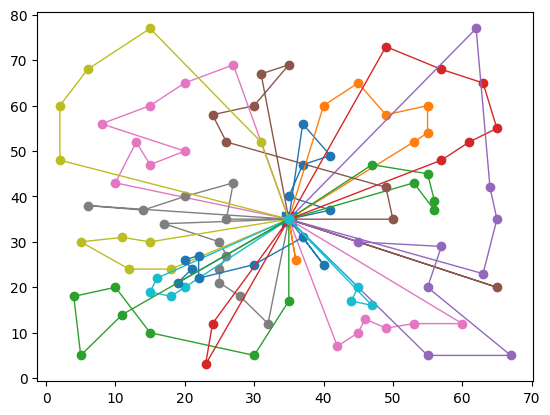

In [104]:
plot_solution(best_tour_aco2, data2,"ACO")


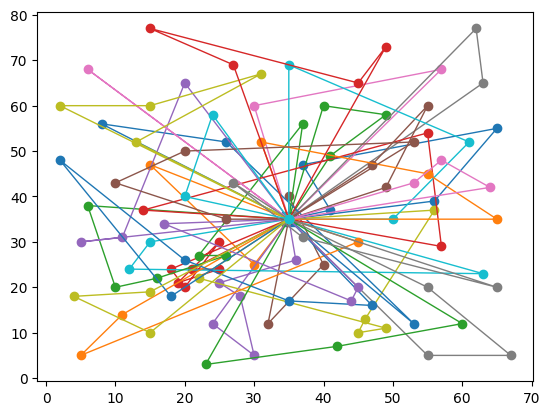

In [105]:
plot_solution(best_tour_ga2, data2, "GA")


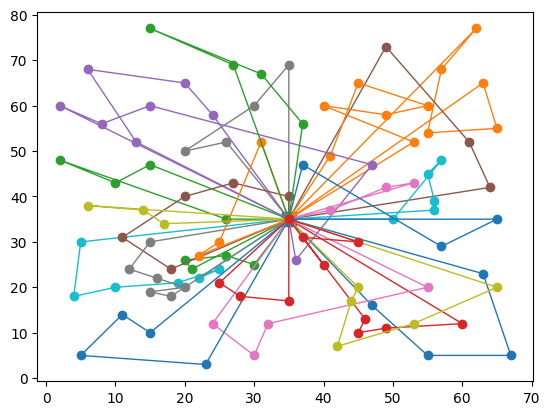

In [106]:
plot_solution(best_tour_tabu2, data2, "Tabu")

In [85]:
data3 = parse_solomon("data/c201.txt")

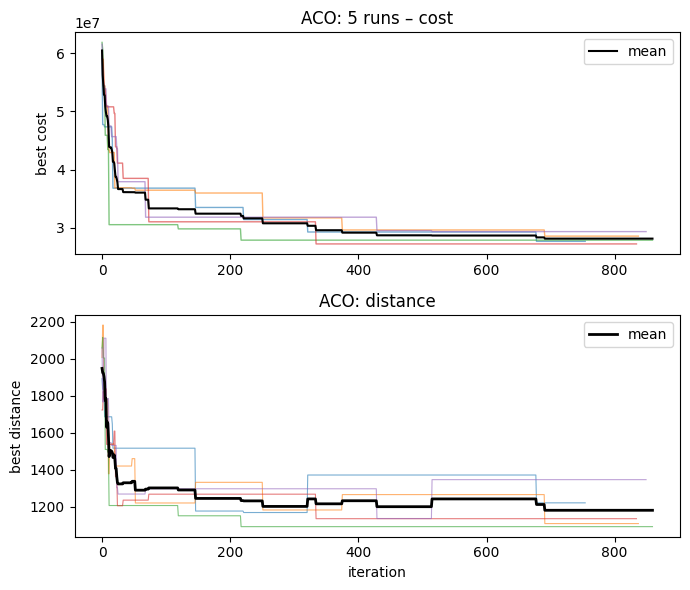

 COST  – min 27213089.16 | avg 28124545.31 | max 29333216.11
 DIST  – min 1091.34 | avg 1179.79 | max 1345.40


In [115]:
make_aco3 = lambda: AntColony(data3, params, evaluate_solution)
results_aco3, histories_aco3, best_tour_aco3 = benchmark_algorithm(make_aco3,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="ACO")


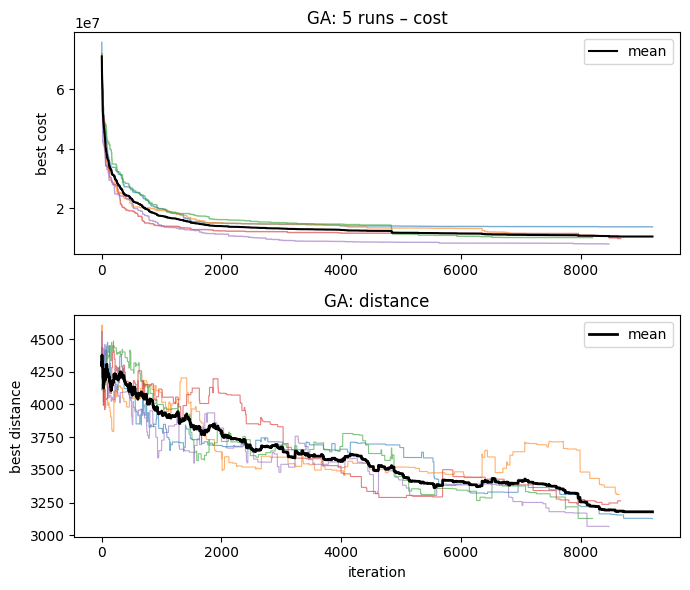

 COST  – min 7935999.73 | avg 10427469.54 | max 13690801.96
 DIST  – min 3066.02 | avg 3179.34 | max 3311.68


In [87]:
make_ga3 = lambda: GeneticVRPTW(data3, evaluate_solution, pop_size=25, tournament_k=5, mutation_rate=0.8, crossover_rate=0.9)
results_ga3, histories_ga3, best_tour_ga3 = benchmark_algorithm(make_ga3,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0}, 
                                         algo_name="GA")

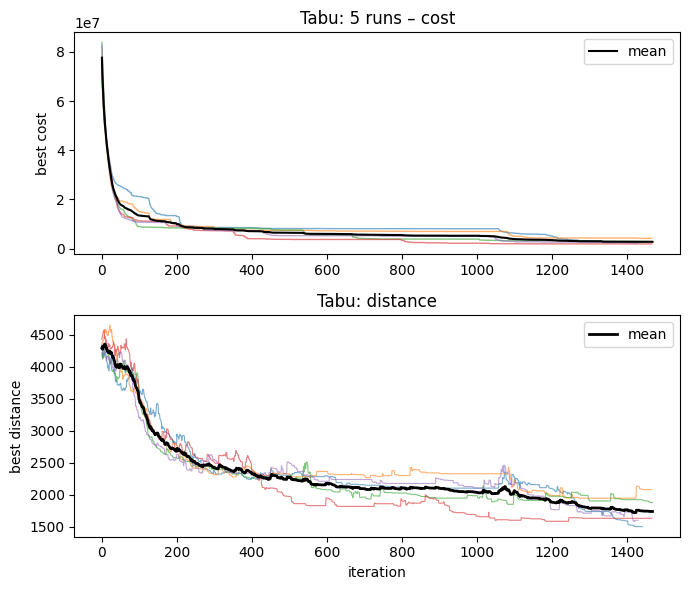

 COST  – min 1879423.91 | avg 2734560.07 | max 4135349.99
 DIST  – min 1500.87 | avg 1738.27 | max 2080.15


In [88]:
make_tabu3 = lambda: TabuSearchVRPTW(data3, evaluate_solution, tabu_params)
results_tabu3, histories_tabu3, best_tour_tabu3 = benchmark_algorithm(make_tabu3,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="Tabu")

In [89]:
data4 = parse_solomon("data/r201.txt")

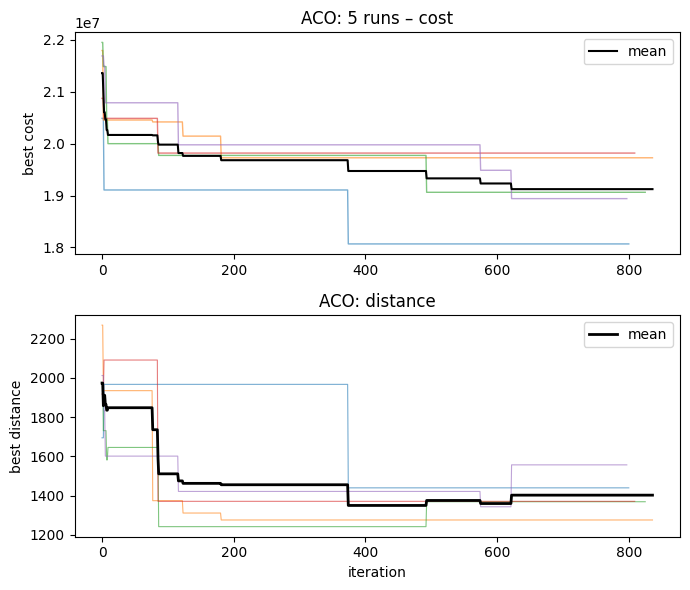

 COST  – min 18066407.52 | avg 19122801.23 | max 19818220.15
 DIST  – min 1276.07 | avg 1402.66 | max 1557.06


In [116]:
make_aco4 = lambda: AntColony(data4, params, evaluate_solution)
results_aco4, histories_aco4, best_tour_aco4 = benchmark_algorithm(make_aco4,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="ACO")


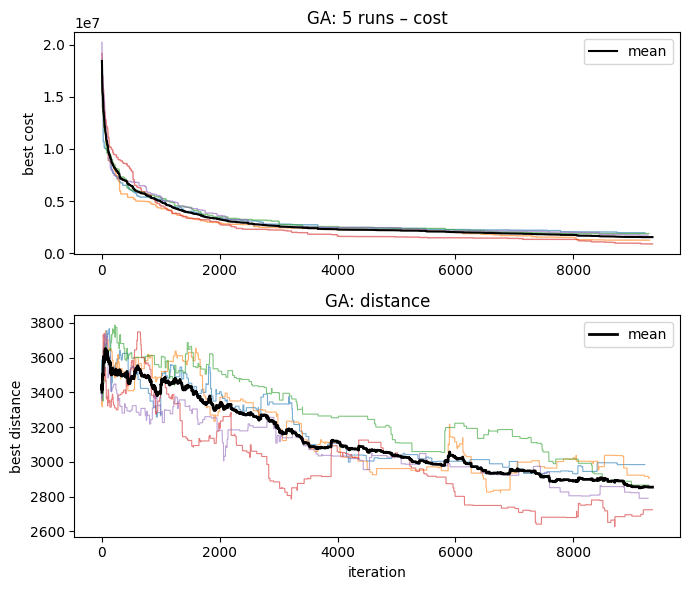

 COST  – min 904598.66 | avg 1556908.51 | max 1970099.22
 DIST  – min 2724.61 | avg 2854.76 | max 2984.61


In [91]:
make_ga4 = lambda: GeneticVRPTW(data4, evaluate_solution, pop_size=25, tournament_k=5, mutation_rate=0.8, crossover_rate=0.9)
results_ga4, histories_ga4, best_tour_ga4 = benchmark_algorithm(make_ga4,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0}, 
                                         algo_name="GA")

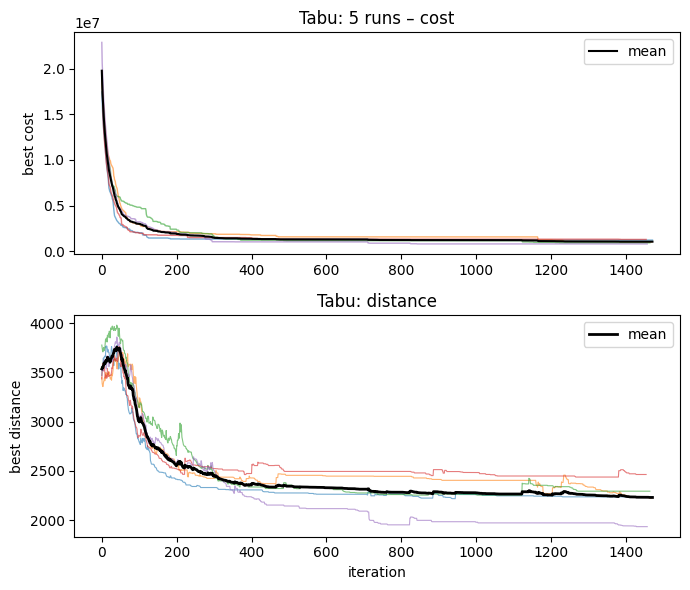

 COST  – min 802890.86 | avg 1051323.29 | max 1294973.43
 DIST  – min 1932.53 | avg 2229.28 | max 2462.77


In [92]:
make_tabu4 = lambda: TabuSearchVRPTW(data4, evaluate_solution, tabu_params)
results_tabu4, histories_tabu4, best_tour_tabu4 = benchmark_algorithm(make_tabu4,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="Tabu")

In [93]:
data5 = parse_solomon("data/rc101.txt")


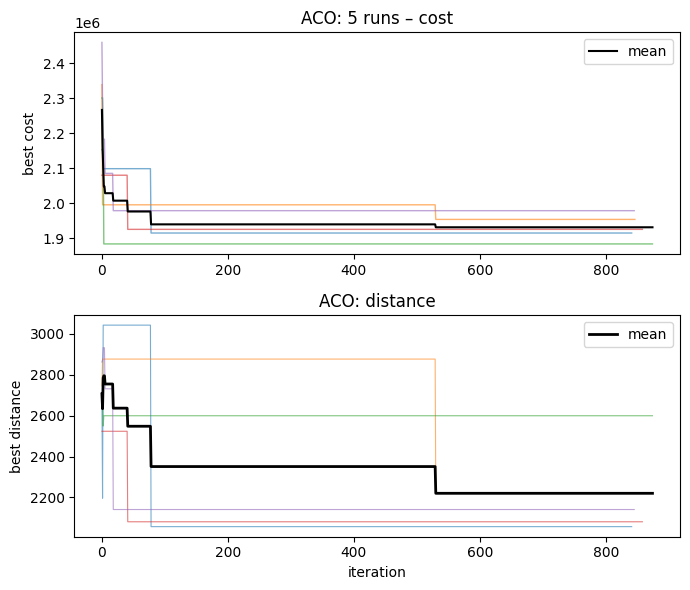

 COST  – min 1883688.28 | avg 1931197.18 | max 1978589.90
 DIST  – min 2057.32 | avg 2220.33 | max 2599.46


In [117]:

make_aco5 = lambda: AntColony(data5, params, evaluate_solution)
results_aco5, histories_aco5, best_tour_aco5 = benchmark_algorithm(make_aco5,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="ACO")


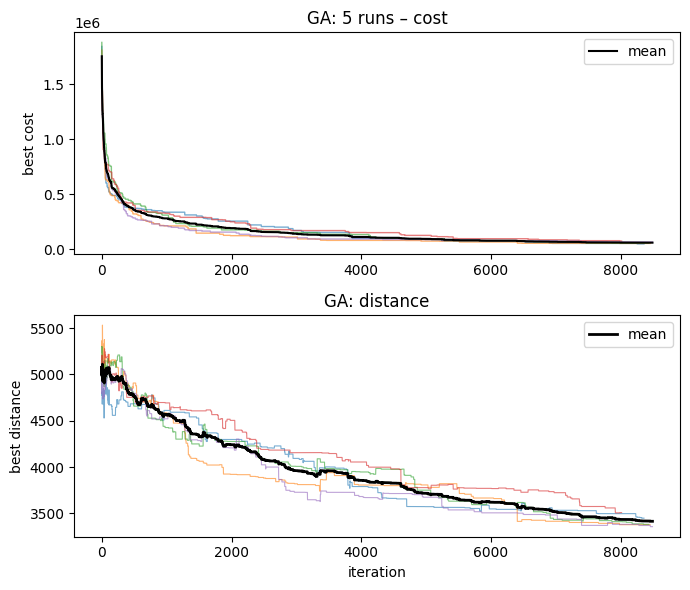

 COST  – min 48706.48 | avg 60048.44 | max 74358.90
 DIST  – min 3356.56 | avg 3414.44 | max 3508.37


In [95]:

make_ga5 = lambda: GeneticVRPTW(data5, evaluate_solution, pop_size=25, tournament_k=5, mutation_rate=0.8, crossover_rate=0.9)
results_ga5, histories_ga5, best_tour_ga5 = benchmark_algorithm(make_ga5,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0}, 
                                         algo_name="GA")


d:\University\semestr_6\venv_6semestr\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


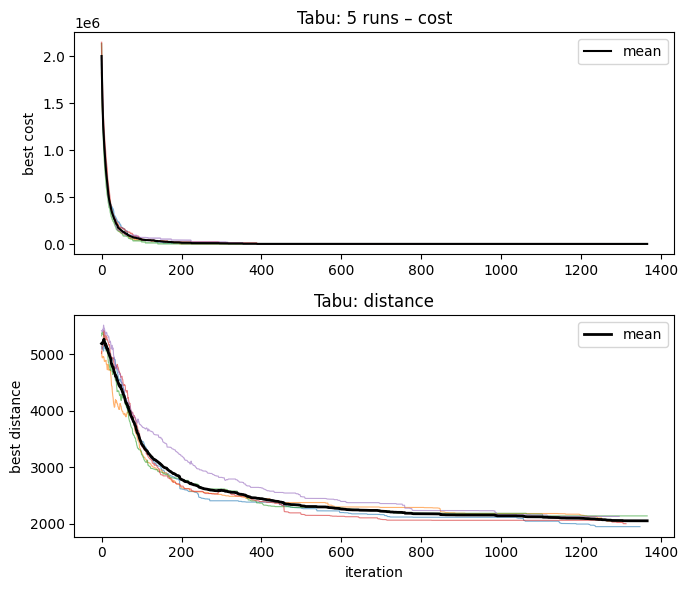

 COST  – min 1949.75 | avg 2052.95 | max 2139.47
 DIST  – min 1949.75 | avg 2052.95 | max 2139.47


In [96]:

make_tabu5 = lambda: TabuSearchVRPTW(data5, evaluate_solution, tabu_params)
results_tabu5, histories_tabu5, best_tour_tabu5 = benchmark_algorithm(make_tabu5,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="Tabu")

In [9]:
data6 = parse_solomon("data/rc201.txt")


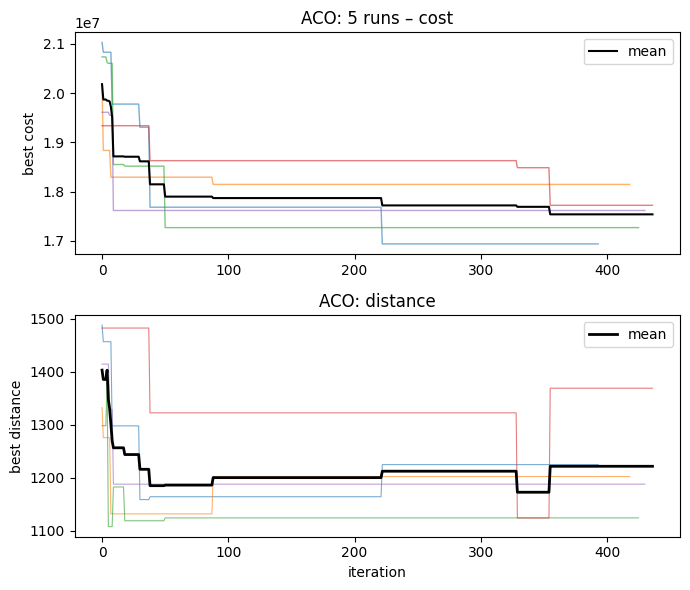

 COST  – min 16937688.93 | avg 17538615.63 | max 18146784.69
 DIST  – min 1124.59 | avg 1221.99 | max 1369.29


In [10]:

make_aco6 = lambda: AntColony(data6, params, evaluate_solution)
results_aco6, histories_aco6, best_tour_aco6 = benchmark_algorithm(make_aco6,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="ACO")


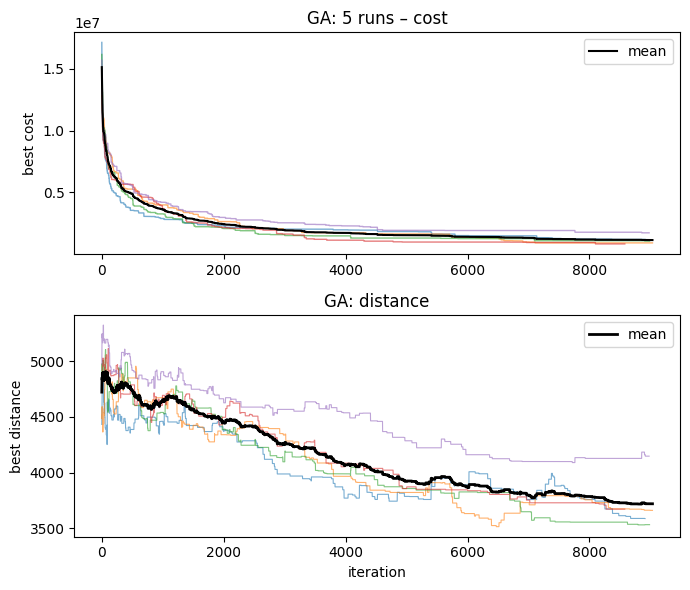

 COST  – min 826397.00 | avg 1140599.06 | max 1724271.78
 DIST  – min 3534.04 | avg 3721.18 | max 4147.99


In [99]:

make_ga6 = lambda: GeneticVRPTW(data6, evaluate_solution, pop_size=25, tournament_k=5, mutation_rate=0.8, crossover_rate=0.9)
results_ga6, histories_ga6, best_tour_ga6 = benchmark_algorithm(make_ga6,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0}, 
                                         algo_name="GA")


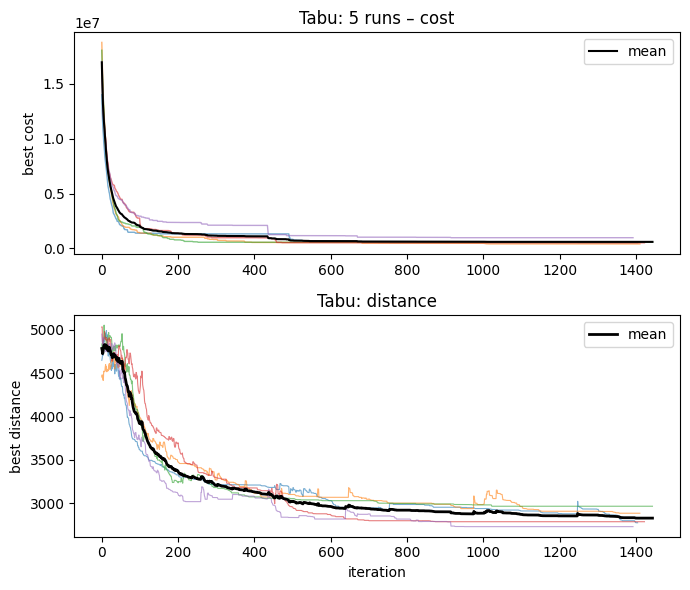

 COST  – min 411164.46 | avg 598196.68 | max 977916.01
 DIST  – min 2731.54 | avg 2829.81 | max 2966.60


In [100]:

make_tabu6 = lambda: TabuSearchVRPTW(data6, evaluate_solution, tabu_params)
results_tabu6, histories_tabu6, best_tour_tabu6 = benchmark_algorithm(make_tabu6,
                                         n_runs=5,
                                         run_kwargs={"time_limit": 60.0},
                                         algo_name="Tabu")